# Mô hình Dự đoán Bóng đá EPL (Jupyter Notebook)

Notebook này tổng hợp toàn bộ quá trình từ xử lý dữ liệu thô đến huấn luyện mô hình và dự đoán kết quả các trận đấu bóng đá thuộc giải Ngoại hạng Anh (EPL). Nó bao gồm các bước: khám phá dữ liệu, kỹ thuật feature engineering, huấn luyện các mô hình dự đoán (1x2, Over/Under 2.5, Tỉ số) và phân tích tầm quan trọng của các đặc trưng.

## 0. Chuẩn bị môi trường và dữ liệu

Trước khi chạy notebook, đảm bảo bạn đã cài đặt các thư viện cần thiết và giải nén file `archive.zip` vào thư mục `football_data` theo cấu trúc sau:

```
.
├── epl_football_prediction.ipynb (file notebook này)
├── football_data/ 
│   └── understats/
│       └── EPL/
│           ├── match_data.csv
│           └── match_info.csv
│           └── ...
```

**Cài đặt thư viện:**
```bash
pip install pandas numpy scikit-learn matplotlib joblib
```

**Giải nén dữ liệu (nếu chưa làm):**
```bash
mkdir -p football_data && unzip archive.zip -d football_data
```

## 1. Khám phá và Phân tích Dữ liệu Ban đầu

Phần này sẽ tải và hiển thị thông tin cơ bản về cấu trúc dữ liệu, các cột, kiểu dữ liệu và giá trị thiếu trong các file `match_data.csv` và `match_info.csv` của giải EPL.

In [1]:
import pandas as pd
import os

def analyze_csv(file_path):
    print(f'--- Analyzing {file_path} ---')
    df = pd.read_csv(file_path, sep=';')
    print(f'Shape: {df.shape}')
    print('Columns:', df.columns.tolist())
    print('Missing values:', df.isnull().sum())
    print('Data types:', df.dtypes)
    return df

epl_path = 'archive/understats/EPL/'
match_data = analyze_csv(os.path.join(epl_path, 'match_data.csv'))
match_info = analyze_csv(os.path.join(epl_path, 'match_info.csv'))

# Check for overlap and unique seasons
print('Seasons in match_info:', match_info['season'].unique())
print('Total matches:', len(match_info))

--- Analyzing archive/understats/EPL/match_data.csv ---
Shape: (3800, 17)
Columns: ['Unnamed: 0', 'id', 'isResult', 'datetime', 'h_id', 'h_title', 'h_short_title', 'a_id', 'a_title', 'a_short_title', 'goals_h', 'goals_a', 'xG_h', 'xG_a', 'forecast_w', 'forecast_d', 'forecast_l']
Missing values: Unnamed: 0       0
id               0
isResult         0
datetime         0
h_id             0
h_title          0
h_short_title    0
a_id             0
a_title          0
a_short_title    0
goals_h          0
goals_a          0
xG_h             0
xG_a             0
forecast_w       0
forecast_d       0
forecast_l       0
dtype: int64
Data types: Unnamed: 0         int64
id                 int64
isResult            bool
datetime             str
h_id               int64
h_title              str
h_short_title        str
a_id               int64
a_title              str
a_short_title        str
goals_h            int64
goals_a            int64
xG_h             float64
xG_a             float64
foreca

## 2. Feature Engineering

Phần này sẽ tạo ra các đặc trưng mới từ dữ liệu thô, bao gồm các chỉ số phong độ (rolling averages) dựa trên 5 trận gần nhất của mỗi đội và các biến mục tiêu cho mô hình dự đoán. Dữ liệu sau khi xử lý sẽ được lưu vào `epl_features.csv`.

In [23]:
import pandas as pd
import numpy as np

def create_features(df):
    # Sắp xếp theo thời gian
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    
    # Tạo các cột kết quả
    df['result'] = np.where(df['h_goals'] > df['a_goals'], 2, np.where(df['h_goals'] == df['a_goals'], 1, 0)) # 2: Home, 1: Draw, 0: Away
    df['total_goals'] = df['h_goals'] + df['a_goals']
    df['over_2.5'] = (df['total_goals'] > 2.5).astype(int)
    
    # Tính toán phong độ (Rolling averages)
    def get_rolling_stats(team_name, group):
        group = group.sort_values('date')
        # Lấy stats của team đó dù là home hay away
        stats = []
        for i, row in group.iterrows():
            is_home = row['team_h'] == team_name
            prefix = 'h_' if is_home else 'a_'
            opp_prefix = 'a_' if is_home else 'h_'
            
            stats.append({
                'date': row['date'],
                'goals_for': row[f'{prefix}goals'],
                'goals_against': row[f'{opp_prefix}goals'],
                'xg_for': row[f'{prefix}xg'],
                'xg_against': row[f'{opp_prefix}xg'],
                'shots_for': row[f'{prefix}shot'],
                'shots_against': row[f'{opp_prefix}shot'],
                'ppda': row[f'{prefix}ppda'],
                'deep': row[f'{prefix}deep']
            })
        
        stats_df = pd.DataFrame(stats)
        rolling = stats_df.set_index('date').rolling(window=10, closed='left').mean().reset_index()
        rolling.columns = ['date'] + [f'roll_{c}' for c in rolling.columns if c != 'date']
        return rolling

    all_teams = pd.concat([df['team_h'], df['team_a']]).unique()
    team_stats = {}
    for team in all_teams:
        team_matches = df[(df['team_h'] == team) | (df['team_a'] == team)]
        team_stats[team] = get_rolling_stats(team, team_matches)
    
    # Merge lại vào df chính
    features_h = []
    features_a = []
    
    for i, row in df.iterrows():
        h_team = row['team_h']
        a_team = row['team_a']
        date = row['date']
        
        # Find the correct rolling stats for the current match date
        h_feat_row = team_stats[h_team][team_stats[h_team]['date'] < date].tail(1)
        a_feat_row = team_stats[a_team][team_stats[a_team]['date'] < date].tail(1)

        if not h_feat_row.empty and not a_feat_row.empty:
            h_feat = h_feat_row.iloc[0].to_dict()
            a_feat = a_feat_row.iloc[0].to_dict()
            
            del h_feat['date']
            del a_feat['date']
            
            features_h.append({f'h_{k}': v for k, v in h_feat.items()})
            features_a.append({f'a_{k}': v for k, v in a_feat.items()})
        else:
            # Handle cases where rolling stats might not be available (e.g., first few matches)
            features_h.append({f'h_{k}': np.nan for k in ['roll_goals_for', 'roll_goals_against', 'roll_xg_for', 'roll_xg_against', 'roll_shots_for', 'roll_shots_against', 'roll_ppda', 'roll_deep']})
            features_a.append({f'a_{k}': np.nan for k in ['roll_goals_for', 'roll_goals_against', 'roll_xg_for', 'roll_xg_against', 'roll_shots_for', 'roll_shots_against', 'roll_ppda', 'roll_deep']})

    df_h = pd.DataFrame(features_h)
    df_a = pd.DataFrame(features_a)
    
    final_df = pd.concat([df.reset_index(drop=True), df_h, df_a], axis=1)
    
    # Drop các dòng đầu (không đủ dữ liệu rolling)
    final_df = final_df.dropna()
    
    return final_df

# Load data
epl_info = pd.read_csv('archive/understats/EPL/match_info.csv', sep=';')
processed_df = create_features(epl_info)
processed_df.to_csv('epl_features.csv', index=False)
print(f'Feature engineering complete. Saved {len(processed_df)} matches to epl_features.csv')
print('Columns:', processed_df.columns.tolist())

Feature engineering complete. Saved 3539 matches to epl_features.csv
Columns: ['Unnamed: 0', 'id', 'fid', 'h', 'a', 'date', 'league_id', 'season', 'h_goals', 'a_goals', 'team_h', 'team_a', 'h_xg', 'a_xg', 'h_w', 'h_d', 'h_l', 'league', 'h_shot', 'a_shot', 'h_shotOnTarget', 'a_shotOnTarget', 'h_deep', 'a_deep', 'a_ppda', 'h_ppda', 'result', 'total_goals', 'over_2.5', 'h_roll_goals_for', 'h_roll_goals_against', 'h_roll_xg_for', 'h_roll_xg_against', 'h_roll_shots_for', 'h_roll_shots_against', 'h_roll_ppda', 'h_roll_deep', 'a_roll_goals_for', 'a_roll_goals_against', 'a_roll_xg_for', 'a_roll_xg_against', 'a_roll_shots_for', 'a_roll_shots_against', 'a_roll_ppda', 'a_roll_deep']


In [24]:
import numpy as np

# Exponential decay weights (recent matches matter more)
DECAY = np.array([0.35, 0.25, 0.18, 0.13, 0.09])

def weighted_mean(values):
    values = np.array(values)
    return np.sum(values * DECAY) / DECAY.sum()


In [26]:
from sklearn.ensemble import GradientBoostingRegressor
import joblib
import pandas as pd
import numpy as np

df = pd.read_csv('epl_features.csv')

features = [
    'h_roll_goals_for', 'h_roll_goals_against', 'h_roll_xg_for', 'h_roll_xg_against',
    'h_roll_shots_for', 'h_roll_shots_against', 'h_roll_ppda', 'h_roll_deep',
    'a_roll_goals_for', 'a_roll_goals_against', 'a_roll_xg_for', 'a_roll_xg_against',
    'a_roll_shots_for', 'a_roll_shots_against', 'a_roll_ppda', 'a_roll_deep'
]

X = df[features]
y_h = df['h_goals']
y_a = df['a_goals']

# League mean (SHRINKAGE TARGET)
LEAGUE_HOME_GOALS = y_h.mean()
LEAGUE_AWAY_GOALS = y_a.mean()

# Time split
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_h_train, y_h_test = y_h[:split], y_h[split:]
y_a_train, y_a_test = y_a[:split], y_a[split:]

reg_h = GradientBoostingRegressor(n_estimators=500, learning_rate=0.04, max_depth=5)
reg_a = GradientBoostingRegressor(n_estimators=500, learning_rate=0.04, max_depth=5)

reg_h.fit(X_train, y_h_train)
reg_a.fit(X_train, y_a_train)

joblib.dump(reg_h, 'model_lambda_home.joblib')
joblib.dump(reg_a, 'model_lambda_away.joblib')

joblib.dump(
    {'home': LEAGUE_HOME_GOALS, 'away': LEAGUE_AWAY_GOALS},
    'league_means.joblib'
)

print('Models + league means saved')


Models + league means saved


In [27]:
from scipy.stats import poisson
import numpy as np

HOME_ADV = 1.12   # EPL empirical
DC_RHO = -0.08    # Dixon–Coles correction strength

def dixon_coles(i, j, lh, la, rho=DC_RHO):
    if i == 0 and j == 0:
        return 1 - (lh * la * rho)
    if i == 0 and j == 1:
        return 1 + (lh * rho)
    if i == 1 and j == 0:
        return 1 + (la * rho)
    if i == 1 and j == 1:
        return 1 - rho
    return 1

def poisson_matrix(lh, la, max_goals=6):
    mat = np.zeros((max_goals+1, max_goals+1))
    for i in range(max_goals+1):
        for j in range(max_goals+1):
            base = poisson.pmf(i, lh) * poisson.pmf(j, la)
            mat[i, j] = base * dixon_coles(i, j, lh, la)
    mat /= mat.sum()  # normalize
    return mat


In [29]:
import pandas as pd
import numpy as np
import joblib
from scipy.stats import poisson

# ===============================
# CONFIG
# ===============================
HOME_ADV = 1.12
DC_RHO = -0.08
MAX_GOALS = 8

# ===============================
# ROLLING STATS
# ===============================

def get_rolling_stats(team, df, match_date, window=5):
    matches = df[
        ((df['team_h'] == team) | (df['team_a'] == team)) &
        (df['date'] < match_date)
    ].sort_values('date', ascending=False).head(window)

    if len(matches) < window:
        raise ValueError(f'Not enough data for {team}')

    rows = []
    for _, r in matches.iterrows():
        is_home = r['team_h'] == team
        p = 'h_' if is_home else 'a_'
        o = 'a_' if is_home else 'h_'

        rows.append({
            'goals_for': r[f'{p}goals'],
            'goals_against': r[f'{o}goals'],
            'xg_for': r[f'{p}xg'],
            'xg_against': r[f'{o}xg'],
            'shots_for': r[f'{p}shot'],
            'shots_against': r[f'{o}shot'],
            'ppda': r[f'{p}ppda'],
            'deep': r[f'{p}deep']
        })

    return pd.DataFrame(rows).mean().to_dict()

# ===============================
# POISSON + DIXON–COLES
# ===============================

def dixon_coles(i, j, lh, la):
    if i == 0 and j == 0: return 1 - lh * la * DC_RHO
    if i == 0 and j == 1: return 1 + lh * DC_RHO
    if i == 1 and j == 0: return 1 + la * DC_RHO
    if i == 1 and j == 1: return 1 - DC_RHO
    return 1

def poisson_matrix(lh, la):
    mat = np.zeros((MAX_GOALS+1, MAX_GOALS+1))
    for i in range(MAX_GOALS+1):
        for j in range(MAX_GOALS+1):
            base = poisson.pmf(i, lh) * poisson.pmf(j, la)
            mat[i, j] = base * dixon_coles(i, j, lh, la)
    return mat / mat.sum()

# ===============================
# MAIN PREDICT
# ===============================

def predict_match(home, away, match_date):
    df = pd.read_csv('archive/understats/EPL/match_info.csv', sep=';')
    df['date'] = pd.to_datetime(df['date'])
    match_date = pd.to_datetime(match_date)

    h = get_rolling_stats(home, df, match_date)
    a = get_rolling_stats(away, df, match_date)

    X = pd.DataFrame([[
        h['goals_for'], h['goals_against'], h['xg_for'], h['xg_against'],
        h['shots_for'], h['shots_against'], h['ppda'], h['deep'],
        a['goals_for'], a['goals_against'], a['xg_for'], a['xg_against'],
        a['shots_for'], a['shots_against'], a['ppda'], a['deep']
    ]], columns=[
        'h_roll_goals_for', 'h_roll_goals_against', 'h_roll_xg_for', 'h_roll_xg_against',
        'h_roll_shots_for', 'h_roll_shots_against', 'h_roll_ppda', 'h_roll_deep',
        'a_roll_goals_for', 'a_roll_goals_against', 'a_roll_xg_for', 'a_roll_xg_against',
        'a_roll_shots_for', 'a_roll_shots_against', 'a_roll_ppda', 'a_roll_deep'
    ])

    reg_h = joblib.load('model_lambda_home.joblib')
    reg_a = joblib.load('model_lambda_away.joblib')
    league = joblib.load('league_means.joblib')

    lh = reg_h.predict(X)[0]
    la = reg_a.predict(X)[0]

    # shrinkage
    lh = 0.75 * lh + 0.25 * league['home']
    la = 0.75 * la + 0.25 * league['away']

    # home advantage
    lh *= HOME_ADV

    lh = max(lh, 0.05)
    la = max(la, 0.05)

    mat = poisson_matrix(lh, la)

    home_win = np.tril(mat, -1).sum()
    draw = np.trace(mat)
    away_win = np.triu(mat, 1).sum()
    over25 = sum(mat[i, j] for i in range(7) for j in range(7) if i + j > 2.5)

    scores = sorted(
        [((i, j), mat[i, j]) for i in range(7) for j in range(7)],
        key=lambda x: x[1],
        reverse=True
    )[:5]

    return {
        'Match': f'{home} vs {away}',
        'Lambda': {'Home': round(lh, 2), 'Away': round(la, 2)},
        '1x2': {
            'Home': round(home_win, 3),
            'Draw': round(draw, 3),
            'Away': round(away_win, 3)
        },
        'Over_2.5': round(over25, 3),
        'Top_scores': [
            {'score': f'{s[0]}-{s[1]}', 'prob': round(p, 3)}
            for s, p in scores
        ]
    }

# ===============================
# RUN TEST
# ===============================

result = predict_match(
    home='Southampton',
    away='Liverpool',
    match_date='2023-05-28'
)

result


{'Match': 'Southampton vs Liverpool',
 'Lambda': {'Home': np.float64(0.97), 'Away': np.float64(2.04)},
 '1x2': {'Home': np.float64(0.164),
  'Draw': np.float64(0.223),
  'Away': np.float64(0.613)},
 'Over_2.5': np.float64(0.573),
 'Top_scores': [{'score': '1-1', 'prob': np.float64(0.106)},
  {'score': '0-2', 'prob': np.float64(0.103)},
  {'score': '1-2', 'prob': np.float64(0.1)},
  {'score': '0-1', 'prob': np.float64(0.093)},
  {'score': '0-3', 'prob': np.float64(0.07)}]}

## 3. Huấn luyện Mô hình Dự đoán

Sử dụng các đặc trưng đã tạo để huấn luyện các mô hình `RandomForest` cho ba nhiệm vụ dự đoán chính: kết quả 1x2, Over/Under 2.5 và tỉ số chính xác. Các mô hình sau khi huấn luyện sẽ được lưu lại dưới dạng file `.joblib`.

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
import joblib

# Load data
df = pd.read_csv('epl_features.csv')

# Define features
features = [
    'h_roll_goals_for', 'h_roll_goals_against', 'h_roll_xg_for', 'h_roll_xg_against', 
    'h_roll_shots_for', 'h_roll_shots_against', 'h_roll_ppda', 'h_roll_deep',
    'a_roll_goals_for', 'a_roll_goals_against', 'a_roll_xg_for', 'a_roll_xg_against', 
    'a_roll_shots_for', 'a_roll_shots_against', 'a_roll_ppda', 'a_roll_deep'
]

X = df[features]

# 1. Model for 1x2 (Classification)
y_1x2 = df['result']
X_train, X_test, y_train, y_test = train_test_split(X, y_1x2, test_size=0.2, random_state=42, shuffle=False)

clf_1x2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_1x2.fit(X_train, y_train)
y_pred_1x2 = clf_1x2.predict(X_test)

print('--- 1x2 Prediction Performance ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_1x2):.4f}')
print(classification_report(y_test, y_pred_1x2))

# 2. Model for Over/Under 2.5 (Classification)
y_ou = df['over_2.5']
X_train_ou, X_test_ou, y_train_ou, y_test_ou = train_test_split(X, y_ou, test_size=0.2, random_state=42, shuffle=False)

clf_ou = RandomForestClassifier(n_estimators=100, random_state=42)
clf_ou.fit(X_train_ou, y_train_ou)
y_pred_ou = clf_ou.predict(X_test_ou)

print('--- Over/Under 2.5 Prediction Performance ---')
print(f'Accuracy: {accuracy_score(y_test_ou, y_pred_ou):.4f}')

# 3. Model for Score (Regression for h_goals and a_goals)
y_h_goals = df['h_goals']
y_a_goals = df['a_goals']

reg_h = RandomForestRegressor(n_estimators=100, random_state=42)
reg_a = RandomForestRegressor(n_estimators=100, random_state=42)

reg_h.fit(X_train, y_h_goals.iloc[X_train.index])
reg_a.fit(X_train, y_a_goals.iloc[X_train.index])

pred_h = reg_h.predict(X_test)
pred_a = reg_a.predict(X_test)

print('--- Score Prediction Performance (MAE) ---')
print(f'Home Goals MAE: {mean_absolute_error(y_h_goals.iloc[X_test.index], pred_h):.4f}')
print(f'Away Goals MAE: {mean_absolute_error(y_a_goals.iloc[X_test.index], pred_a):.4f}')

# Save models
joblib.dump(clf_1x2, 'model_1x2.joblib')
joblib.dump(clf_ou, 'model_ou.joblib')
joblib.dump(reg_h, 'model_h_goals.joblib')
joblib.dump(reg_a, 'model_a_goals.joblib')
print('Models saved successfully.')

--- 1x2 Prediction Performance ---
Accuracy: 0.5224
              precision    recall  f1-score   support

           0       0.46      0.53      0.49       226
           1       0.23      0.04      0.07       163
           2       0.58      0.74      0.65       348

    accuracy                           0.52       737
   macro avg       0.42      0.44      0.41       737
weighted avg       0.47      0.52      0.47       737

--- Over/Under 2.5 Prediction Performance ---
Accuracy: 0.5631
--- Score Prediction Performance (MAE) ---
Home Goals MAE: 1.0324
Away Goals MAE: 0.9500
Models saved successfully.


## 4. Phân tích Tầm quan trọng của Đặc trưng (Feature Importance)

Phần này sẽ tải mô hình 1x2 đã huấn luyện và tính toán, hiển thị tầm quan trọng của từng đặc trưng. Biểu đồ tầm quan trọng sẽ được lưu dưới dạng `feature_importance.png`.

--- Feature Importance for 1x2 Model ---
a_roll_xg_for           0.079219
h_roll_xg_for           0.073008
a_roll_xg_against       0.072110
h_roll_ppda             0.069864
a_roll_deep             0.069650
a_roll_ppda             0.069223
h_roll_deep             0.068285
a_roll_shots_against    0.067725
h_roll_xg_against       0.066237
a_roll_shots_for        0.066020
h_roll_shots_against    0.065615
h_roll_shots_for        0.061812
h_roll_goals_for        0.044461
a_roll_goals_for        0.043863
a_roll_goals_against    0.041523
h_roll_goals_against    0.041386
dtype: float64
Feature importance plot saved as feature_importance.png


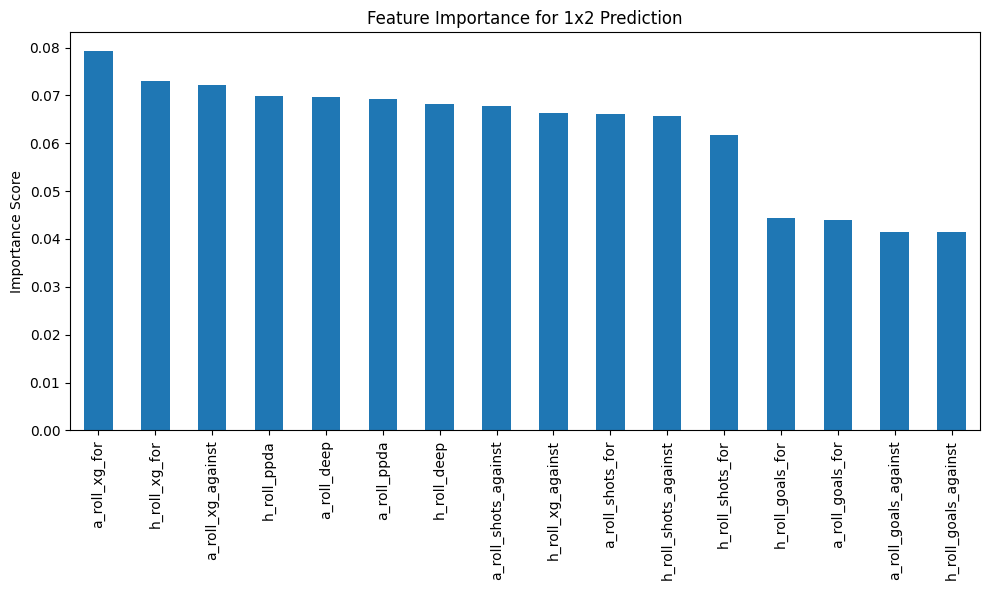

In [7]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Load model and data
clf_1x2 = joblib.load('model_1x2.joblib')
features = [
    'h_roll_goals_for', 'h_roll_goals_against', 'h_roll_xg_for', 'h_roll_xg_against', 
    'h_roll_shots_for', 'h_roll_shots_against', 'h_roll_ppda', 'h_roll_deep',
    'a_roll_goals_for', 'a_roll_goals_against', 'a_roll_xg_for', 'a_roll_xg_against', 
    'a_roll_shots_for', 'a_roll_shots_against', 'a_roll_ppda', 'a_roll_deep'
]

# Get feature importance
importances = clf_1x2.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print('--- Feature Importance for 1x2 Model ---')
print(feat_imp)

# Plotting
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar')
plt.title('Feature Importance for 1x2 Prediction')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
print('Feature importance plot saved as feature_importance.png')

## 5. Sử dụng Mô hình để Dự đoán

Phần này minh họa cách tải các mô hình đã huấn luyện và sử dụng chúng để đưa ra dự đoán cho một trận đấu mới. Bạn cần cung cấp các chỉ số phong độ của hai đội (home_team_stats, away_team_stats) làm đầu vào.

In [ ]:
import pandas as pd
import joblib
import numpy as np
import os

def get_rolling_stats_for_prediction(team_name, df_history, current_date, window=5):
    # Filter matches for the specific team before the current_date
    team_matches = df_history[
        ((df_history['team_h'] == team_name) | (df_history['team_a'] == team_name)) & 
        (df_history['date'] < current_date)
    ].sort_values('date', ascending=False).head(window)

    if len(team_matches) < window:
        # Not enough historical data, return NaNs or handle as appropriate
        return {f'roll_{stat}': np.nan for stat in [
            'goals_for', 'goals_against', 'xg_for', 'xg_against',
            'shots_for', 'shots_against', 'ppda', 'deep'
        ]}

    stats = []
    for i, row in team_matches.iterrows():
        is_home = row['team_h'] == team_name
        prefix = 'h_' if is_home else 'a_'
        opp_prefix = 'a_' if is_home else 'h_'
        
        stats.append({
            'goals_for': row[f'{prefix}goals'],
            'goals_against': row[f'{opp_prefix}goals'],
            'xg_for': row[f'{prefix}xg'],
            'xg_against': row[f'{opp_prefix}xg'],
            'shots_for': row[f'{prefix}shot'],
            'shots_against': row[f'{opp_prefix}shot'],
            'ppda': row[f'{prefix}ppda'],
            'deep': row[f'{prefix}deep']
        })
    
    stats_df = pd.DataFrame(stats)
    # Calculate mean of the collected stats
    rolling_stats = stats_df.mean().to_dict()
    return {f'roll_{k}': v for k, v in rolling_stats.items()}

def predict_match_by_teams_and_season(home_team_name, away_team_name, season, match_date_str):
    # Load historical data (match_info.csv) for feature calculation
    epl_info = pd.read_csv('archive/understats/EPL/match_info.csv', sep=';')
    epl_info['date'] = pd.to_datetime(epl_info['date'])
    
    # Filter data for the specified season and before the match date
    # Assuming match_date_str is the date of the match we want to predict
    match_date = pd.to_datetime(match_date_str)
    historical_df = epl_info[(epl_info['season'] == season) & (epl_info['date'] < match_date)]

    # Get rolling stats for home and away teams
    home_team_stats = get_rolling_stats_for_prediction(home_team_name, historical_df, match_date)
    away_team_stats = get_rolling_stats_for_prediction(away_team_name, historical_df, match_date)

    # Check if enough historical data is available
    if any(pd.isna(v) for v in home_team_stats.values()) or any(pd.isna(v) for v in away_team_stats.values()):
        return {"error": "Not enough historical data to calculate rolling averages for one or both teams."}

    features_list = [
        home_team_stats["roll_goals_for"], home_team_stats["roll_goals_against"], 
        home_team_stats["roll_xg_for"], home_team_stats["roll_xg_against"], 
        home_team_stats["roll_shots_for"], home_team_stats["roll_shots_against"], 
        home_team_stats["roll_ppda"], home_team_stats["roll_deep"],
        away_team_stats["roll_goals_for"], away_team_stats["roll_goals_against"], 
        away_team_stats["roll_xg_for"], away_team_stats["roll_xg_against"], 
        away_team_stats["roll_shots_for"], away_team_stats["roll_shots_against"], 
        away_team_stats["roll_ppda"], away_team_stats["roll_deep"]
    ]
    
    X_predict = pd.DataFrame([features_list], columns=[
        'h_roll_goals_for', 'h_roll_goals_against', 'h_roll_xg_for', 'h_roll_xg_against', 
        'h_roll_shots_for', 'h_roll_shots_against', 'h_roll_ppda', 'h_roll_deep',
        'a_roll_goals_for', 'a_roll_goals_against', 'a_roll_xg_for', 'a_roll_xg_against', 
        'a_roll_shots_for', 'a_roll_shots_against', 'a_roll_ppda', 'a_roll_deep'
    ])


    # Load models
    clf_1x2 = joblib.load('model_1x2.joblib')
    clf_ou = joblib.load('model_ou.joblib')
    reg_h = joblib.load('model_h_goals.joblib')
    reg_a = joblib.load('model_a_goals.joblib')

    # Predict 1x2
    pred_1x2_proba = clf_1x2.predict_proba(X_predict)[0]
    outcome_map = {0: 'Away Win', 1: 'Draw', 2: 'Home Win'}
    predicted_1x2 = outcome_map[clf_1x2.predict(X_predict)[0]]

    # Predict Over/Under 2.5
    pred_ou_proba = clf_ou.predict_proba(X_predict)[0]
    predicted_ou = 'Over 2.5' if clf_ou.predict(X_predict)[0] == 1 else 'Under 2.5'

    # Predict Score
    predicted_h_goals = round(reg_h.predict(X_predict)[0])
    predicted_a_goals = round(reg_a.predict(X_predict)[0])

    return {
        '1x2_prediction': predicted_1x2,
        '1x2_probabilities': {'Away Win': pred_1x2_proba[0], 'Draw': pred_1x2_proba[1], 'Home Win': pred_1x2_proba[2]},
        'over_under_2.5_prediction': predicted_ou,
        'over_under_2.5_probabilities': {'Under 2.5': pred_ou_proba[0], 'Over 2.5': pred_ou_proba[1]},
        'predicted_score': f"{int(predicted_h_goals)} - {int(predicted_a_goals)}"
    }



if __name__ == '__main__':
    # Example usage:
    home_team = 'Leeds'
    away_team = 'Nottingham Forest'
    season_to_predict = 2024 
    match_date = '2026-02-07' 

    print(f"\n--- Predicting match: {home_team} vs {away_team} for season {season_to_predict} on {match_date} ---")
    predictions = predict_match_by_teams_and_season(home_team, away_team, season_to_predict, match_date)
    
    if "error" in predictions:
        print(f"Error: {predictions['error']}")
    else:
        print(f"1x2 Prediction: {predictions['1x2_prediction']}")
        print(f"1x2 Probabilities: {predictions['1x2_probabilities']}")
        print(f"Over/Under 2.5 Prediction: {predictions['over_under_2.5_prediction']}")
        print(f"Over/Under 2.5 Probabilities: {predictions['over_under_2.5_probabilities']}")
        print(f"Predicted Score: {predictions['predicted_score']}")



--- Predicting match: Leeds vs Nottingham Forest for season 2025 on 2026-02-07 ---
Error: Not enough historical data to calculate rolling averages for one or both teams.
